<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Multilevel_Rabi_Dynamics_Comparison_for_Qubits_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Introduction to Multilevel Rabi Dynamics

A physical qubit with finite anharmonicity is more accurately represented as a multilevel quantum oscillator than as an ideal two level system. The lowest two energy eigenstates, $|0\rangle$ and $|1\rangle$, define the computational subspace, whereas the higher states $|2\rangle$, $|3\rangle$, and beyond provide possible leakage channels during strong or spectrally broad control pulses [1–4].

For a weakly anharmonic oscillator, the transition frequencies are separated by the anharmonicity

$$
\alpha
=
\omega_{12}
-
\omega_{01}.
$$

The simulation approximates this system using a truncated Duffing oscillator. In a frame rotating at the drive frequency and under the rotating wave approximation, the Hamiltonian is

$$
\frac{H}{\hbar}
=
\Delta \hat{n}
+
\frac{\alpha}{2}
\hat{n}
\left(
\hat{n}-1
\right)
+
\frac{\Omega_R}{2}
\left(
\hat{a}+\hat{a}^{\dagger}
\right),
$$

where $\hat{a}$ and $\hat{a}^{\dagger}$ are the annihilation and creation operators,

$$
\hat{n}
=
\hat{a}^{\dagger}\hat{a},
$$

$\Delta=\omega_{01}-\omega_d$ is the drive detuning, $\alpha$ is the anharmonicity, and $\Omega_R$ represents the bare $|0\rangle\leftrightarrow|1\rangle$ Rabi angular frequency.

The undriven energy ladder represented by this model follows

$$
\frac{E_n}{\hbar}
=
n\omega_{01}
+
\frac{\alpha}{2}n(n-1),
$$

which gives adjacent transition frequencies

$$
\omega_{n,n+1}
=
\omega_{01}
+
n\alpha.
$$

For $\alpha=0$, the energy levels form a harmonic oscillator with equally spaced transitions. Increasing $|\alpha|$ separates the unwanted $|1\rangle\leftrightarrow|2\rangle$ transition from the intended $|0\rangle\leftrightarrow|1\rangle$ transition, improving spectral selectivity [1,2].

For an ideal resonantly driven two level system initially in $|0\rangle$, the excited state probability follows

$$
P_1(t)
=
\sin^2
\left(
\frac{\Omega_R t}{2}
\right).
$$

With the script setting

$$
\frac{\Omega_R}{2\pi}
=
50\ \mathrm{MHz},
$$

the corresponding ideal Rabi period and ideal $\pi$ pulse duration are

$$
T_R
=
\frac{2\pi}{\Omega_R}
=
20\ \mathrm{ns},
$$

and

$$
t_{\pi}
=
\frac{\pi}{\Omega_R}
=
10\ \mathrm{ns}.
$$

A multilevel device can depart from this sinusoidal result as the drive approaches the anharmonic separation. The useful dimensionless quantity is therefore

$$
\mathcal{S}
=
\frac{\Omega_R}{|\alpha|},
$$

which serves as a simple measure of drive strength relative to spectral selectivity [2,3].

For the three simulated cases,

| Anharmonicity regime | $\alpha/2\pi$ | $\Omega_R/2\pi$ | $\Omega_R/\vert\alpha\vert$ | Expected behavior |
| --- | --- | --- | --- | --- |
| Weak | $-50\ \mathrm{MHz}$ | $50\ \mathrm{MHz}$ | $1.00$ | Strong multilevel participation |
| Moderate | $-200\ \mathrm{MHz}$ | $50\ \mathrm{MHz}$ | $0.25$ | Reduced leakage |
| Strong | $-1000\ \mathrm{MHz}$ | $50\ \mathrm{MHz}$ | $0.05$ | Approximately two level Rabi dynamics |


The drive couples adjacent oscillator states with matrix elements proportional to

$$
\langle n+1|
\hat{a}^{\dagger}
|n\rangle
=
\sqrt{n+1}.
$$

Consequently, a sufficiently strong drive can transfer population beyond $|1\rangle$. The script measures this population as

$$
P_{\mathrm{leak}}(t)
=
\sum_{n=2}^{N-1}P_n(t).
$$

For the four level truncation used here,

$$
P_{\mathrm{leak}}
=
P_2+P_3.
$$

A reduction in the maximum value of $P_1$ therefore represents redistribution of quantum population among multiple levels and associated modifications of the driven dynamics. It is better interpreted as loss of two level selectivity than as a universal shortening of the Rabi oscillation amplitude [2,3].

The heat maps extend the same calculation across drive strength,

$$
P_1
=
P_1
\left(
t,\Omega_R
\right),
$$

and

$$
P_{\mathrm{leak}}
=
P_{\mathrm{leak}}
\left(
t,\Omega_R
\right).
$$

They therefore expose the transition from spectrally selective Rabi oscillations at $\Omega_R/|\alpha|\ll1$ toward increasingly multilevel dynamics as the drive rate approaches the anharmonic separation.

If decoherence is enabled, QuTiP evolves the density operator using a Lindblad master equation [4,5],

$$
\frac{d\rho}{dt}
=
-\frac{i}{\hbar}
[H,\rho]
+
\sum_k
\mathcal{D}
\left[
L_k
\right]\rho,
$$

with

$$
\mathcal{D}[L]\rho
=
L\rho L^{\dagger}
-
\frac{1}{2}
L^{\dagger}L\rho
-
\frac{1}{2}
\rho L^{\dagger}L.
$$

The script introduces energy relaxation using $T_1$ and pure dephasing using $T_{\phi}$. With decoherence disabled, the plots isolate coherent multilevel dynamics caused by finite anharmonicity.

### References

1. Koch, J., Yu, T.M., Gambetta, J., Houck, A.A., Schuster, D.I., Majer, J., Blais, A., Devoret, M.H., Girvin, S.M. and Schoelkopf, R.J. (2007) ‘Charge-insensitive qubit design derived from the Cooper pair box’, *Physical Review A*, 76, 042319. https://doi.org/10.1103/PhysRevA.76.042319

2. Motzoi, F., Gambetta, J.M., Rebentrost, P. and Wilhelm, F.K. (2009) ‘Simple pulses for elimination of leakage in weakly nonlinear qubits’, *Physical Review Letters*, 103, 110501. https://doi.org/10.1103/PhysRevLett.103.110501

3. Gambetta, J.M., Motzoi, F., Merkel, S.T. and Wilhelm, F.K. (2011) ‘Analytic control methods for high-fidelity unitary operations in a weakly nonlinear oscillator’, *Physical Review A*, 83, 012308. https://doi.org/10.1103/PhysRevA.83.012308

4. Krantz, P., Kjaergaard, M., Yan, F., Orlando, T.P., Gustavsson, S. and Oliver, W.D. (2019) ‘A quantum engineer’s guide to superconducting qubits’, *Applied Physics Reviews*, 6, 021318. https://doi.org/10.1063/1.5089550

5. Johansson, J.R., Nation, P.D. and Nori, F. (2013) ‘QuTiP 2: A Python framework for the dynamics of open quantum systems’, *Computer Physics Communications*, 184, pp. 1234–1240. https://doi.org/10.1016/j.cpc.2012.11.019

In [ ]:
!uv pip install qutip matplotlib numpy

In [ ]:
dxfcvbgqwaZSexd

Regime         alpha/2pi (MHz)   Omega/|alpha|      max P1    max leakage
-------------------------------------------------------------------------
Weak                     -50.0           1.000      0.5225         0.6127
Moderate                -200.0           0.250      0.9606         0.0387
Strong                 -1000.0           0.050      0.9982         0.0013


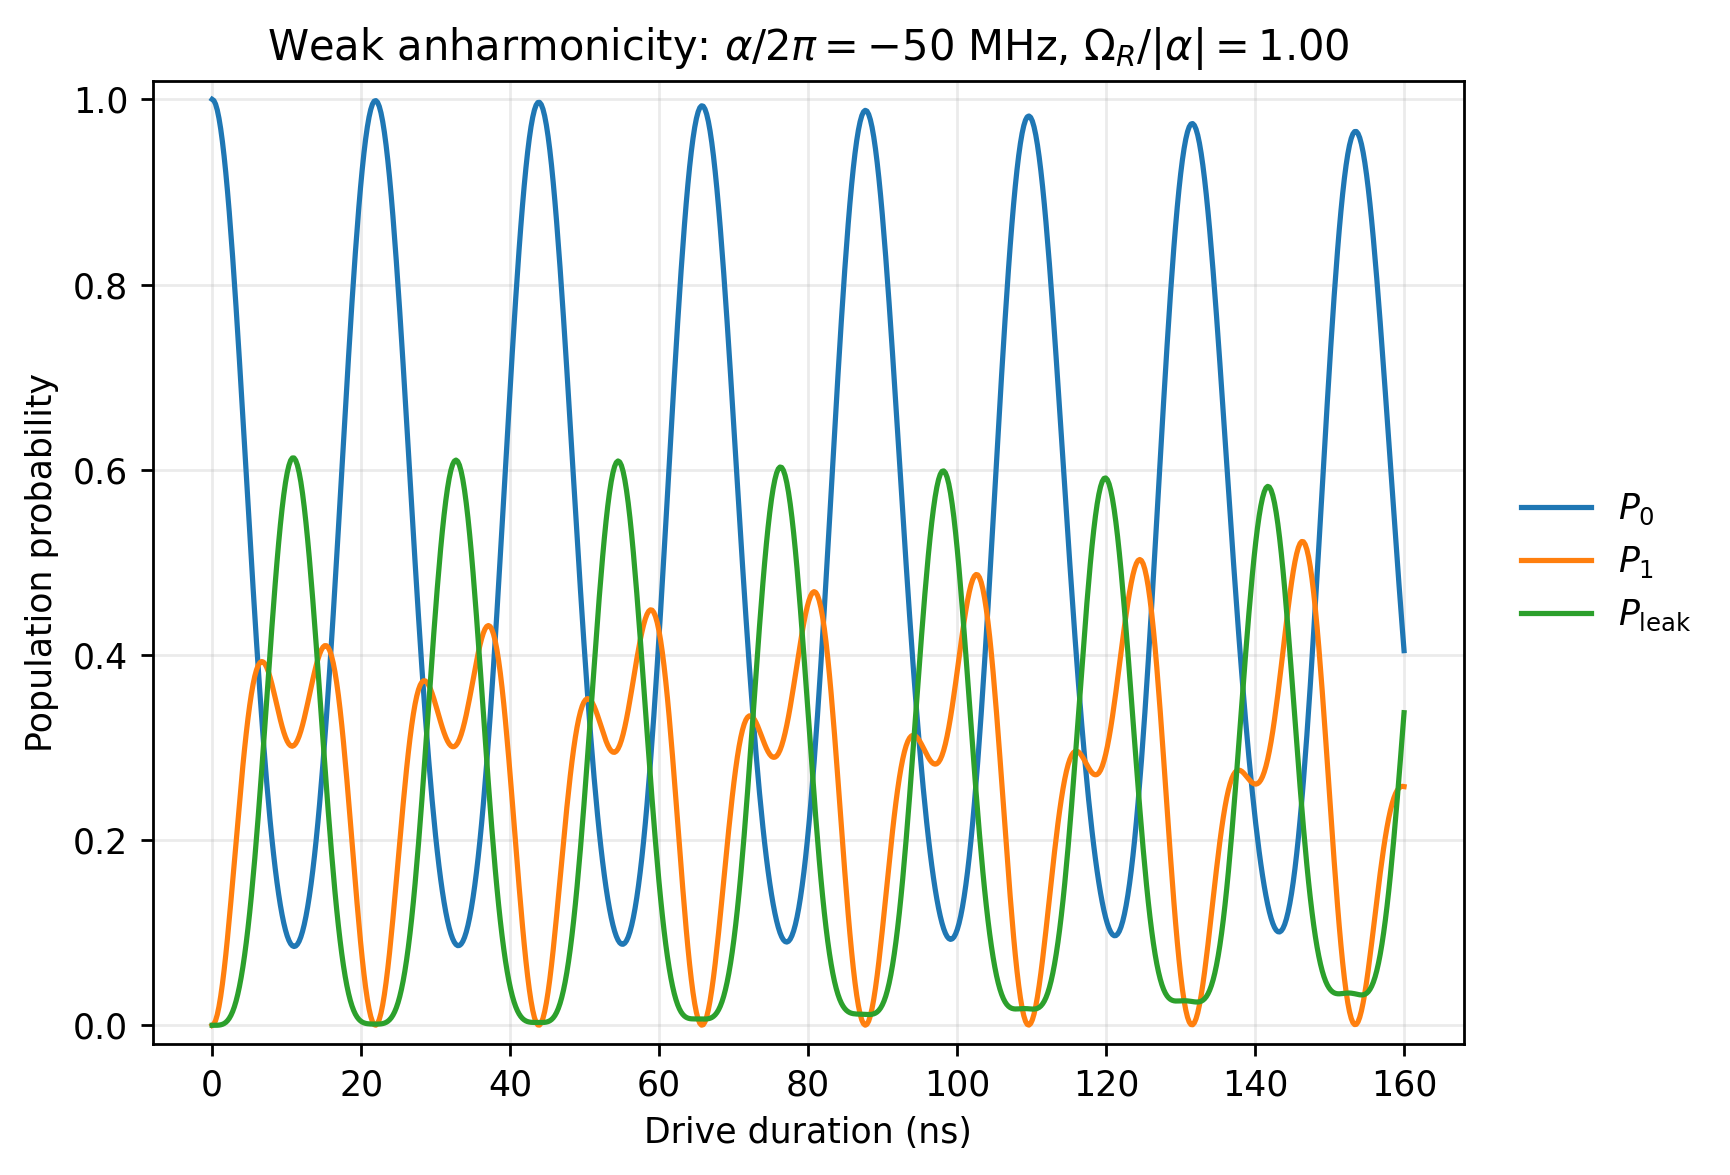

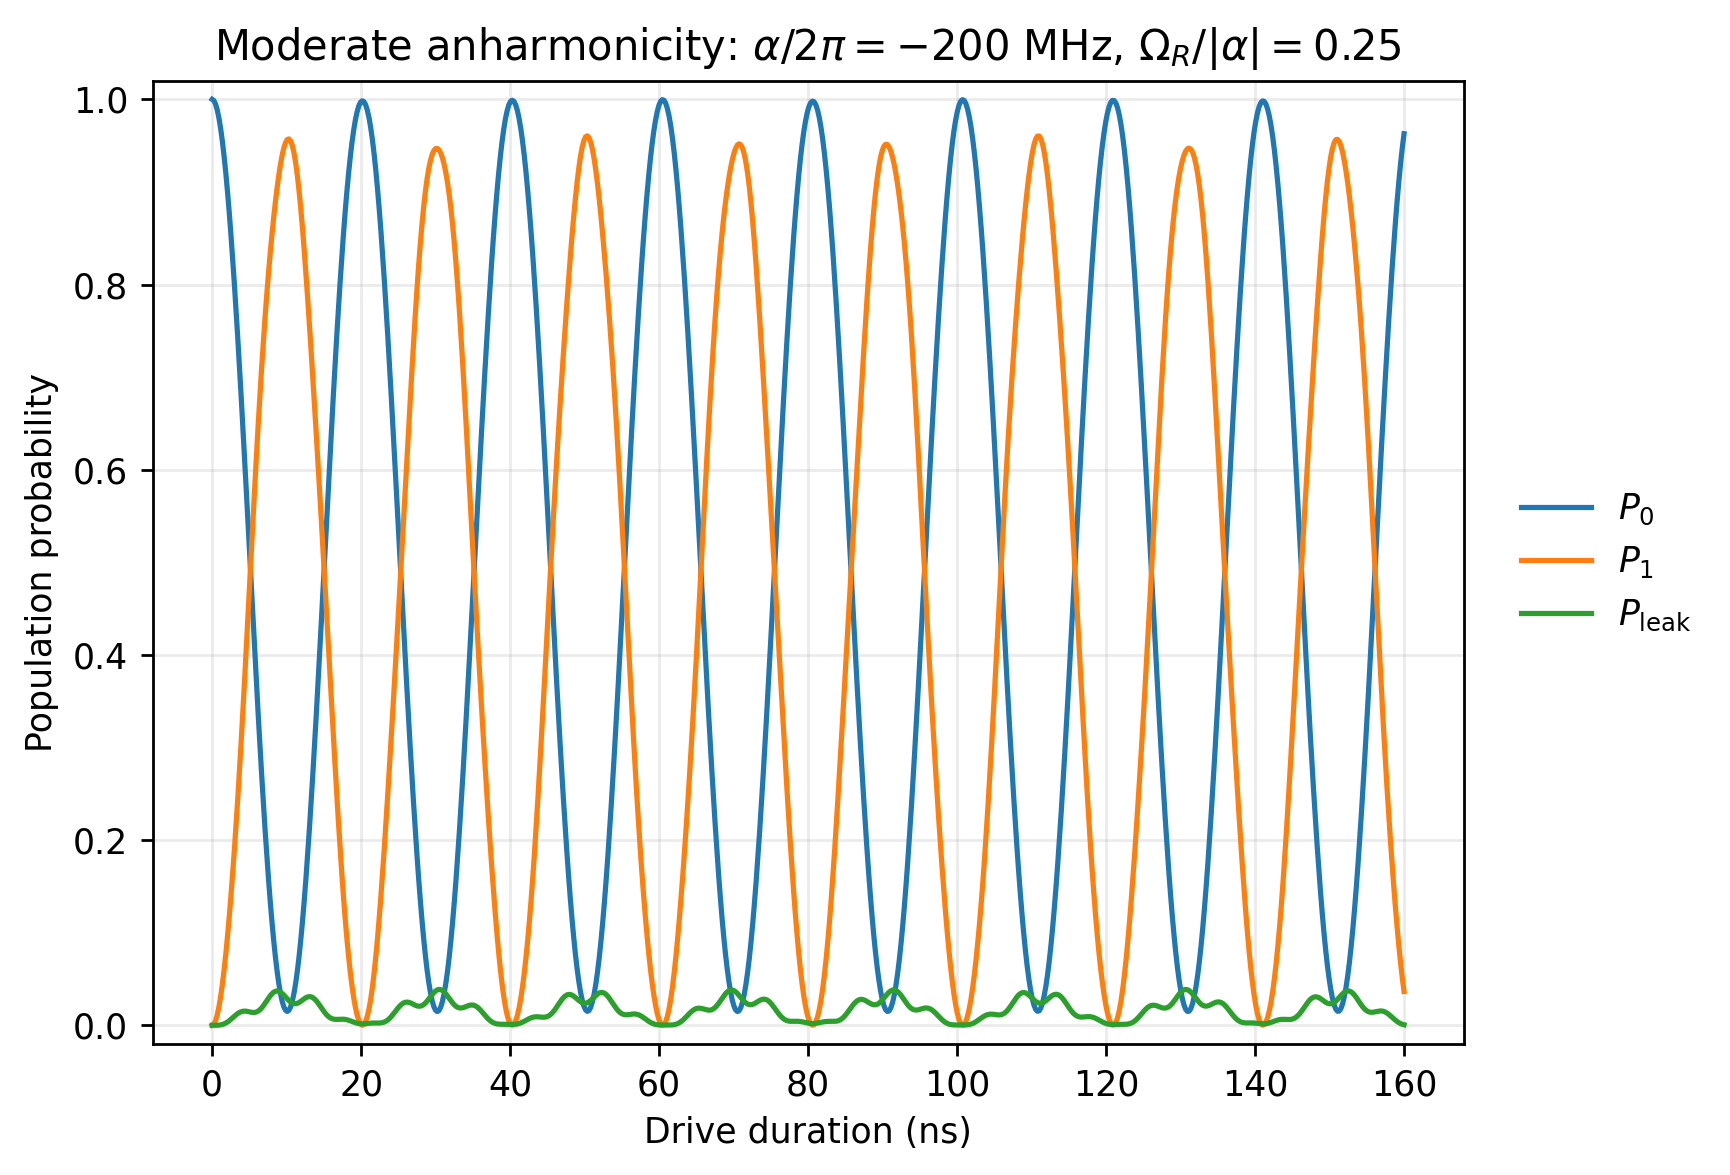

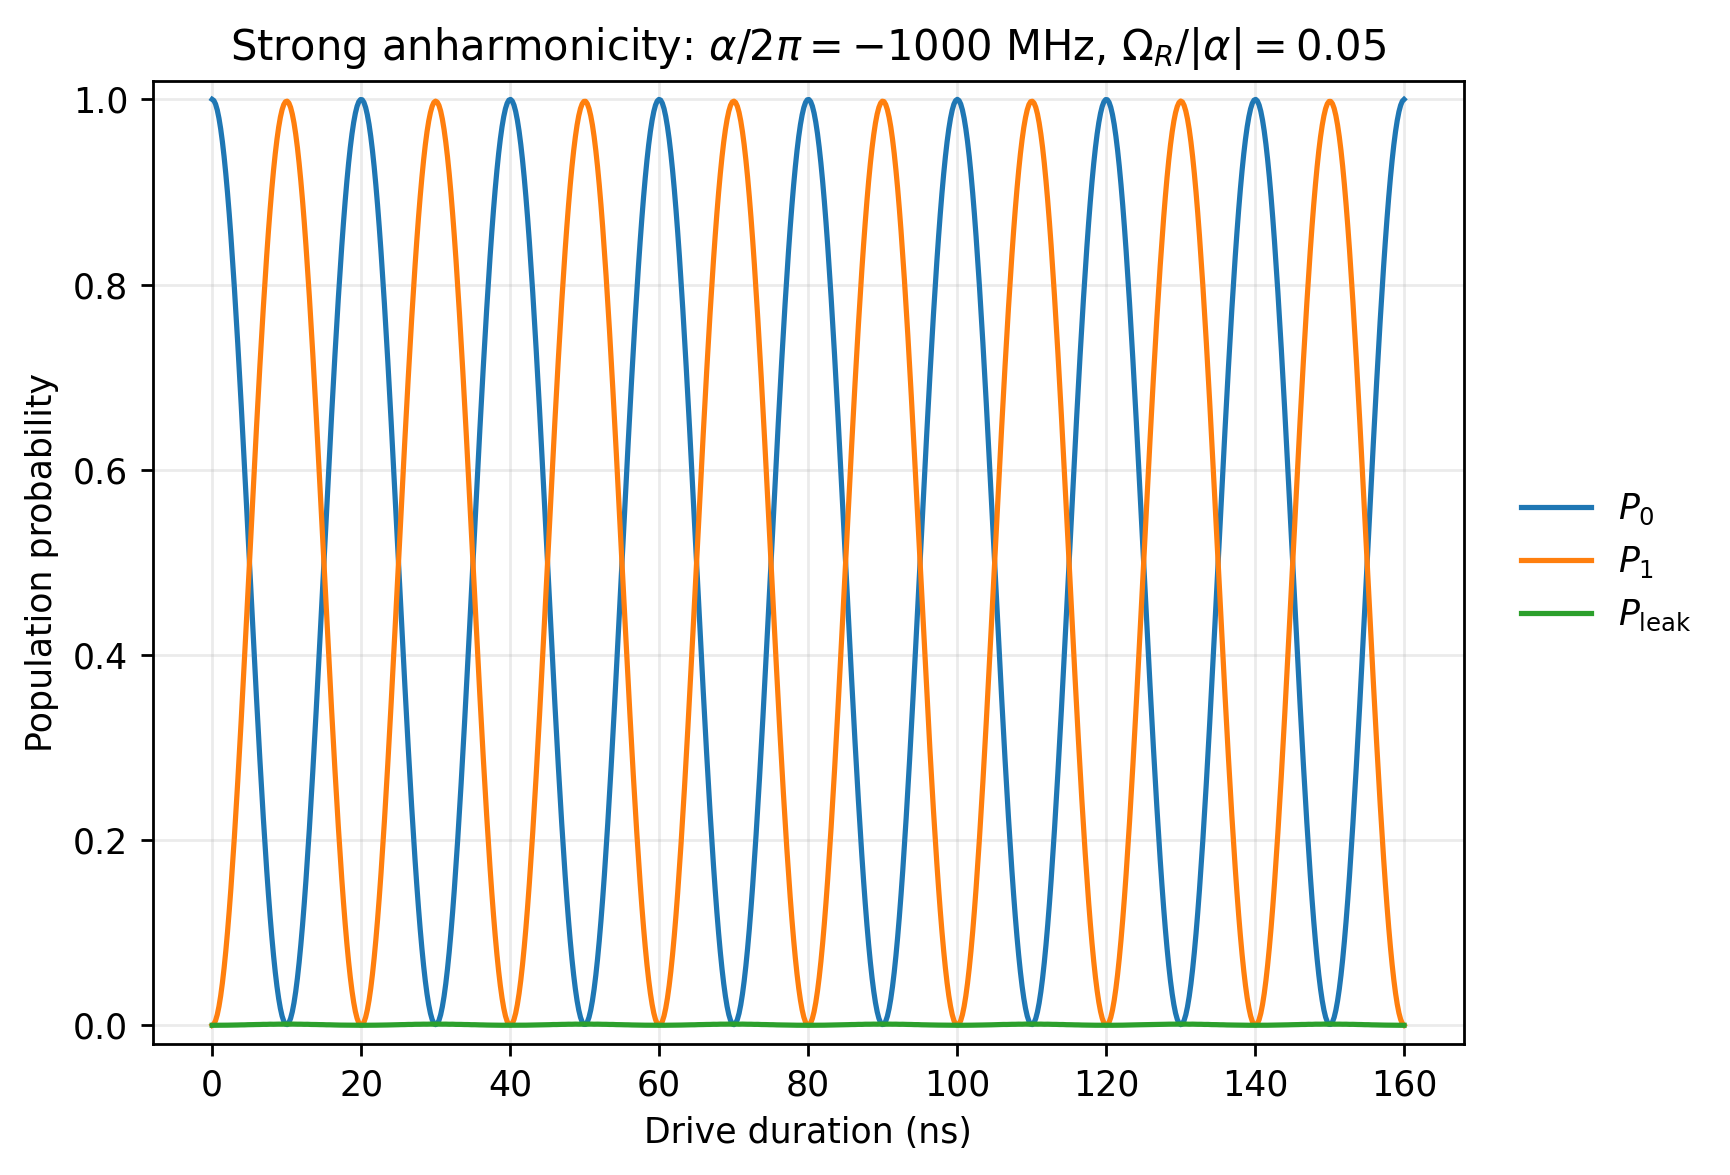

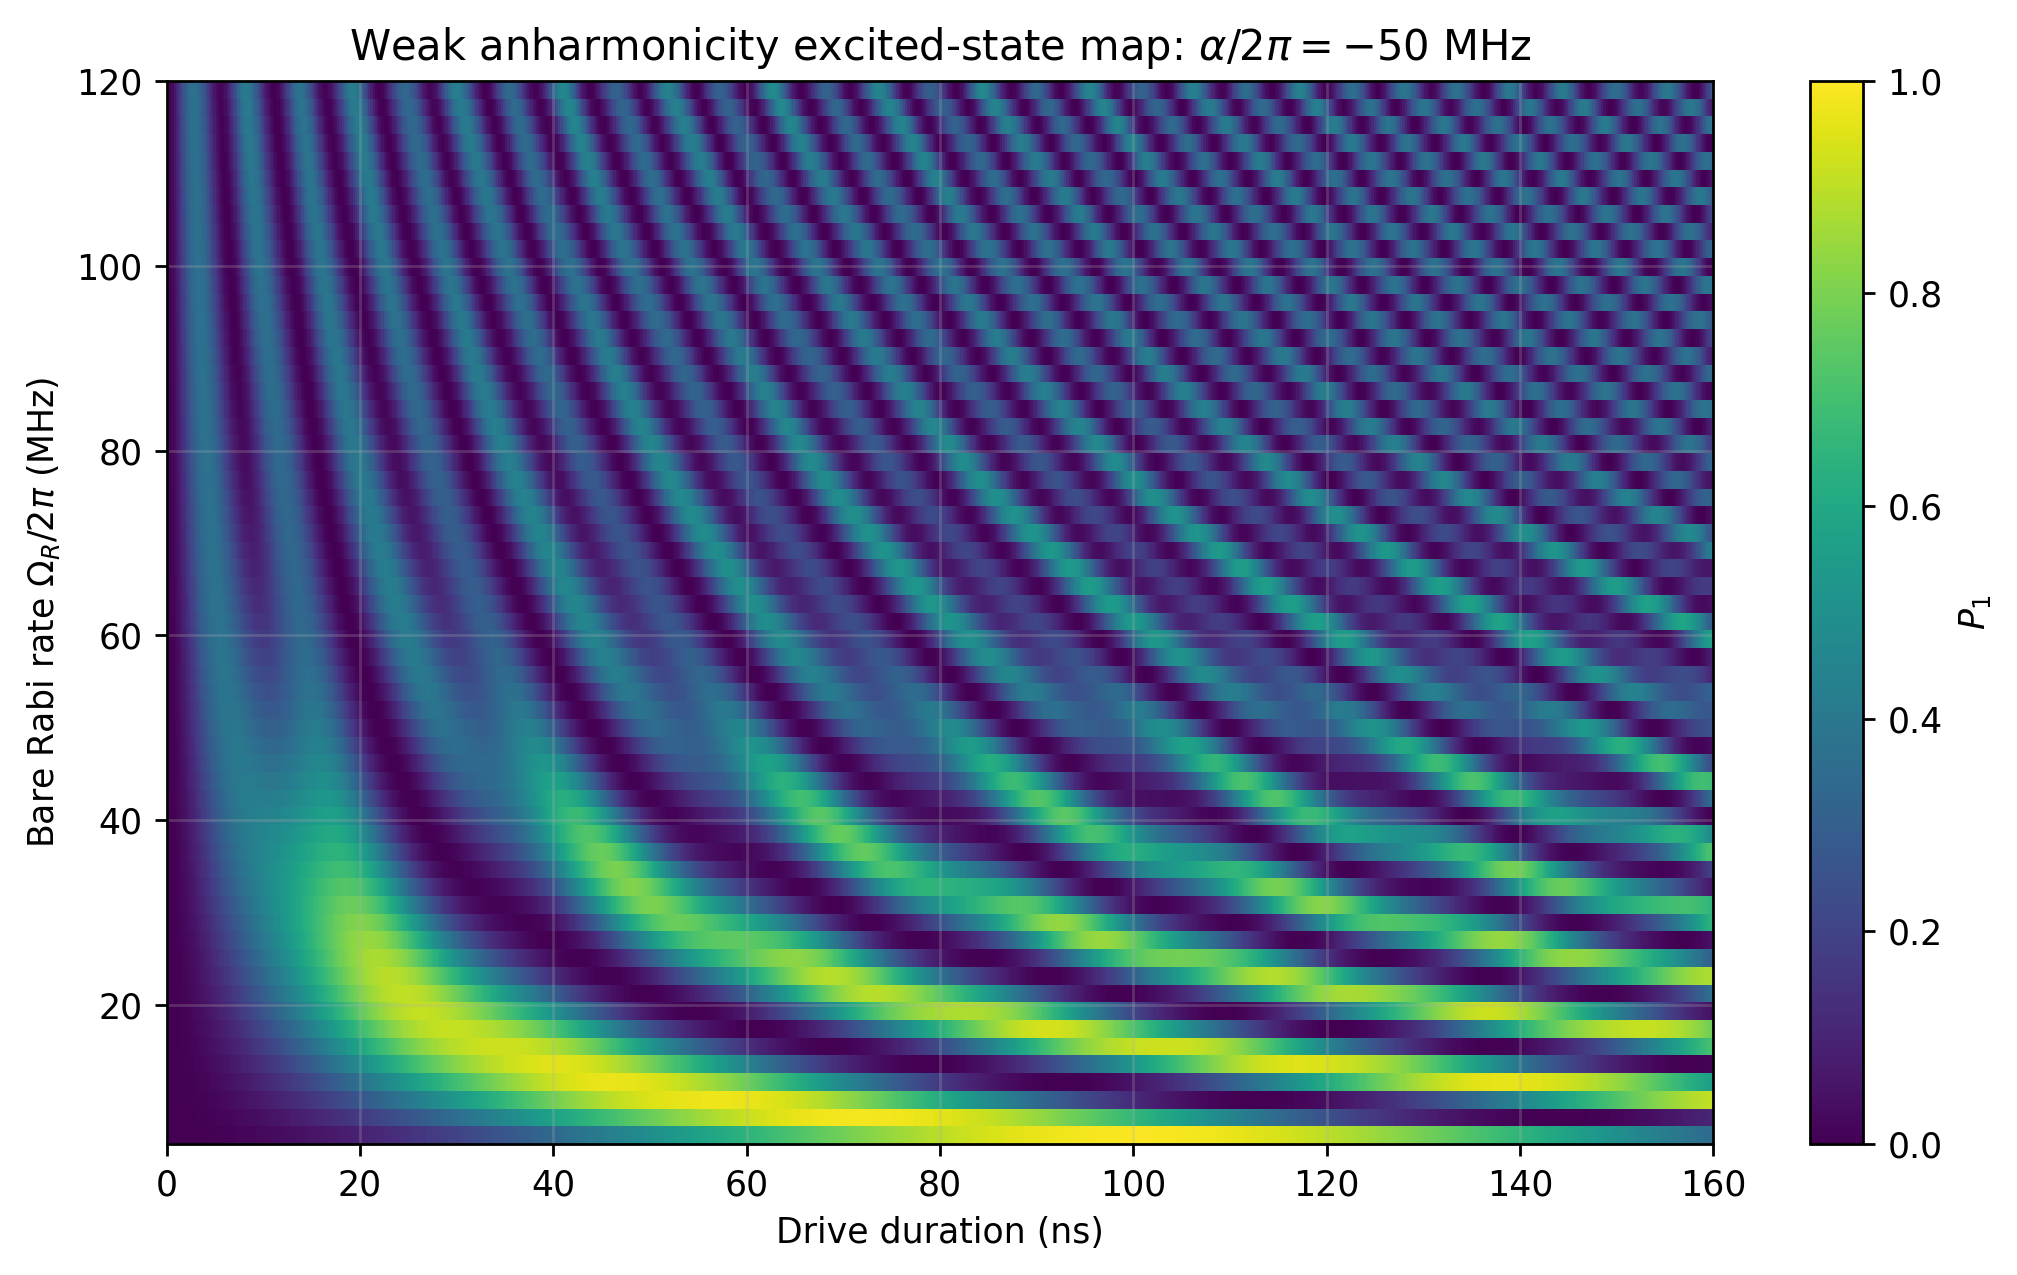

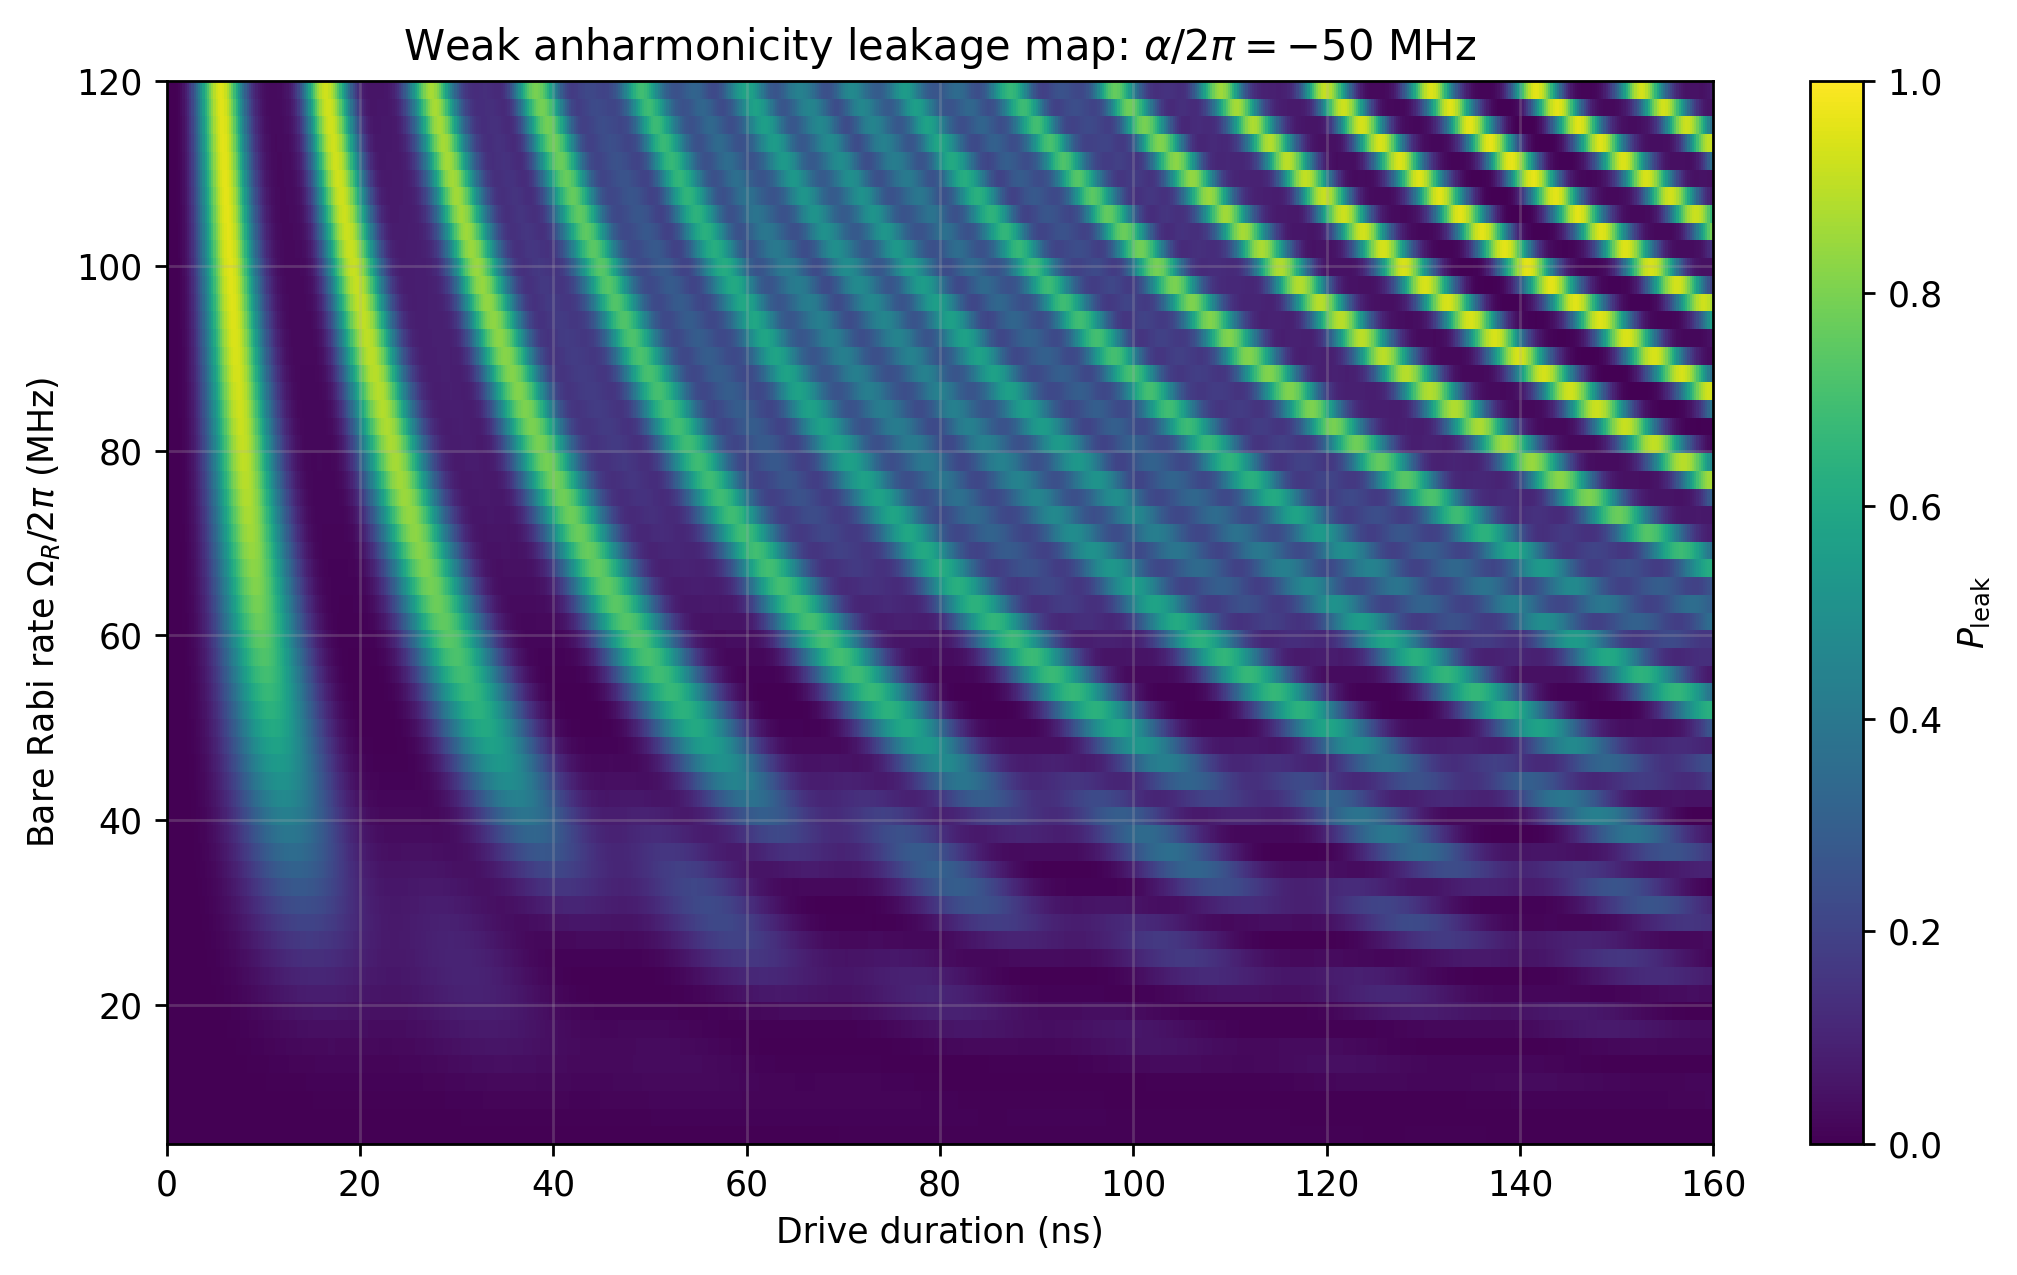

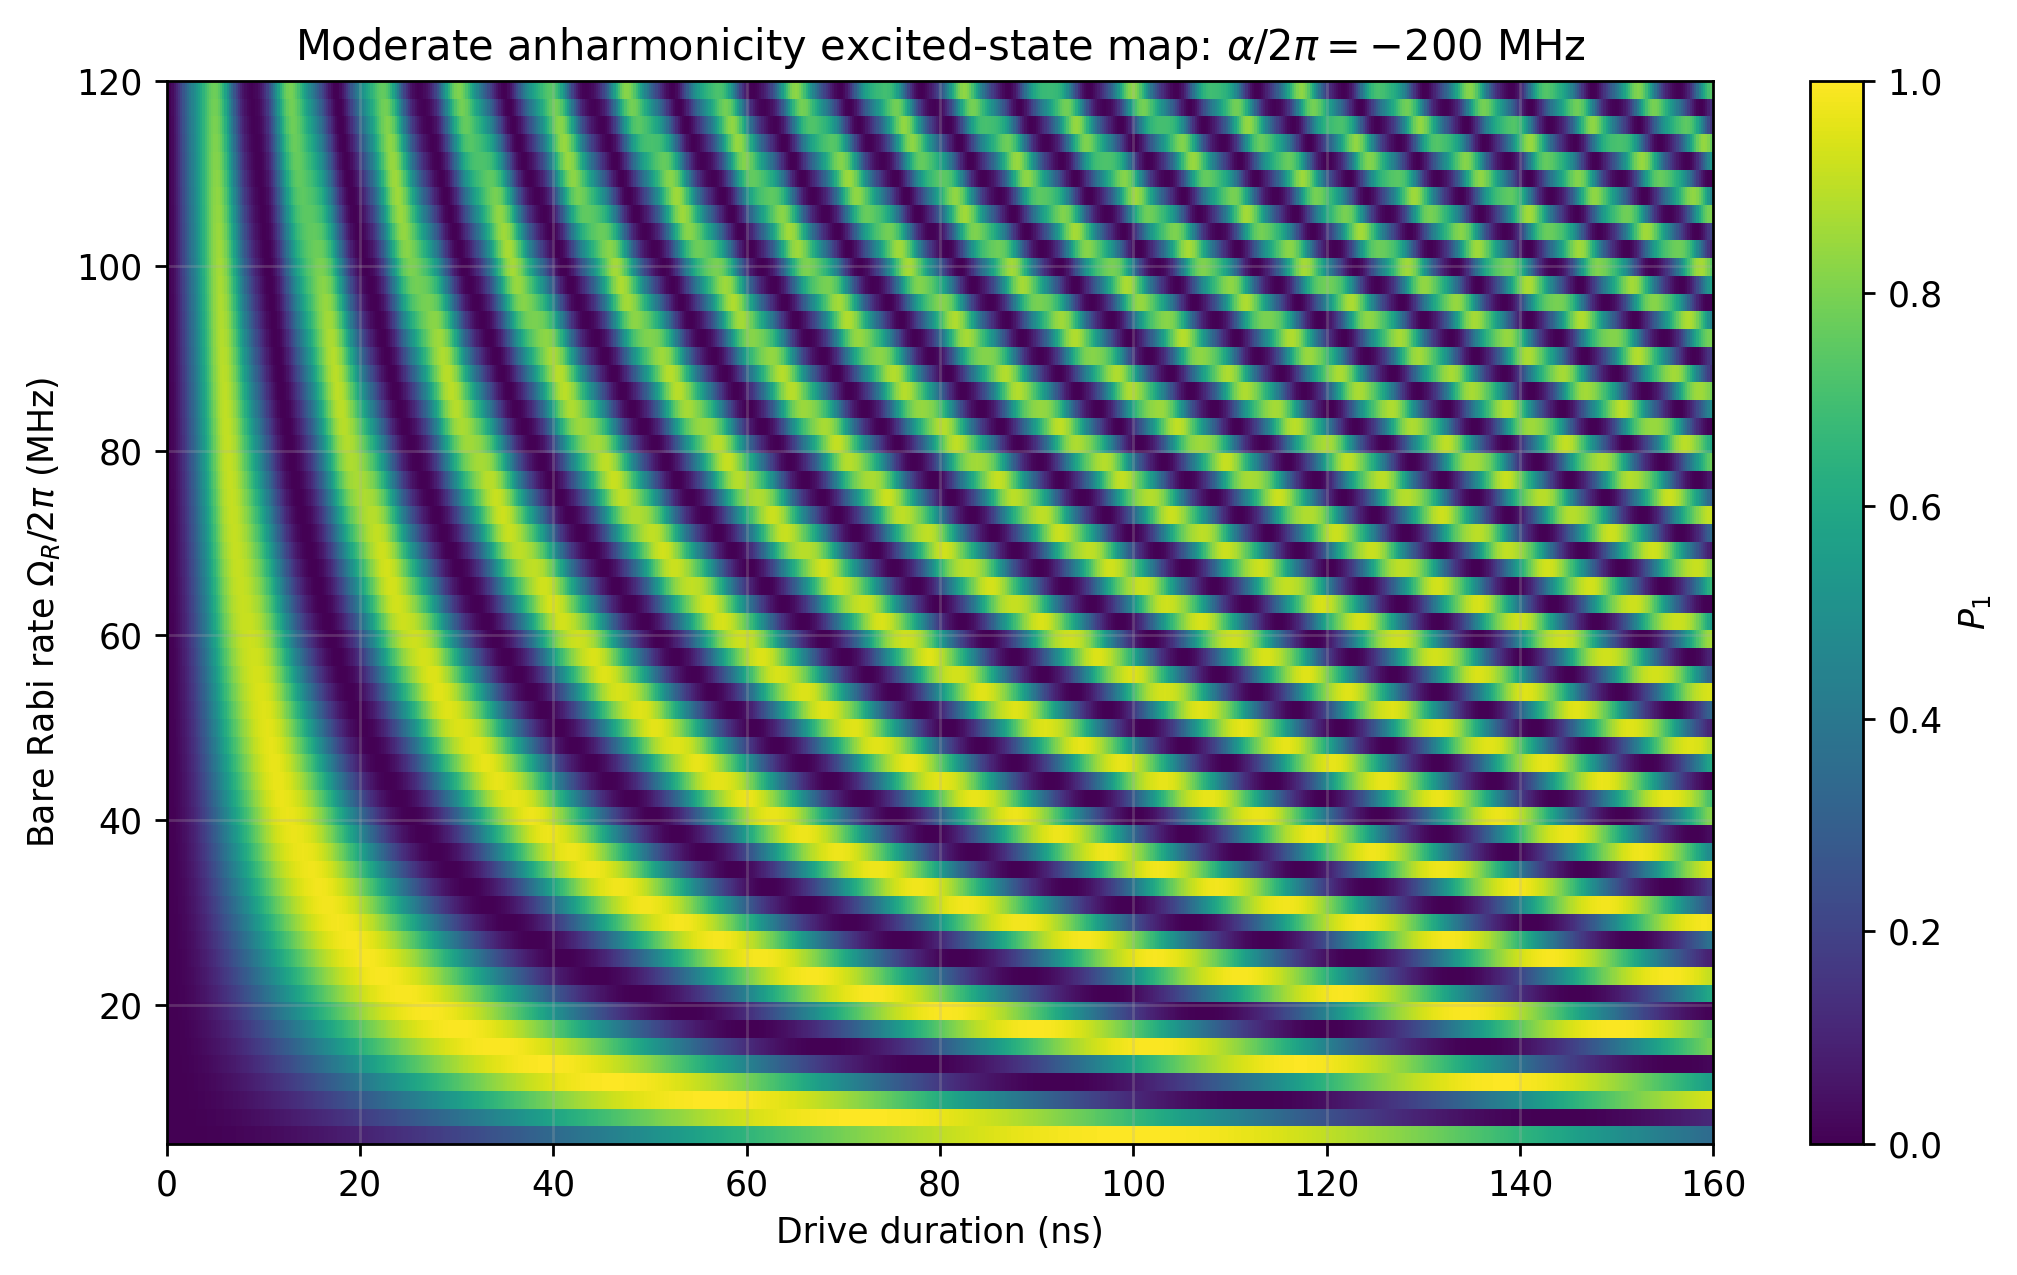

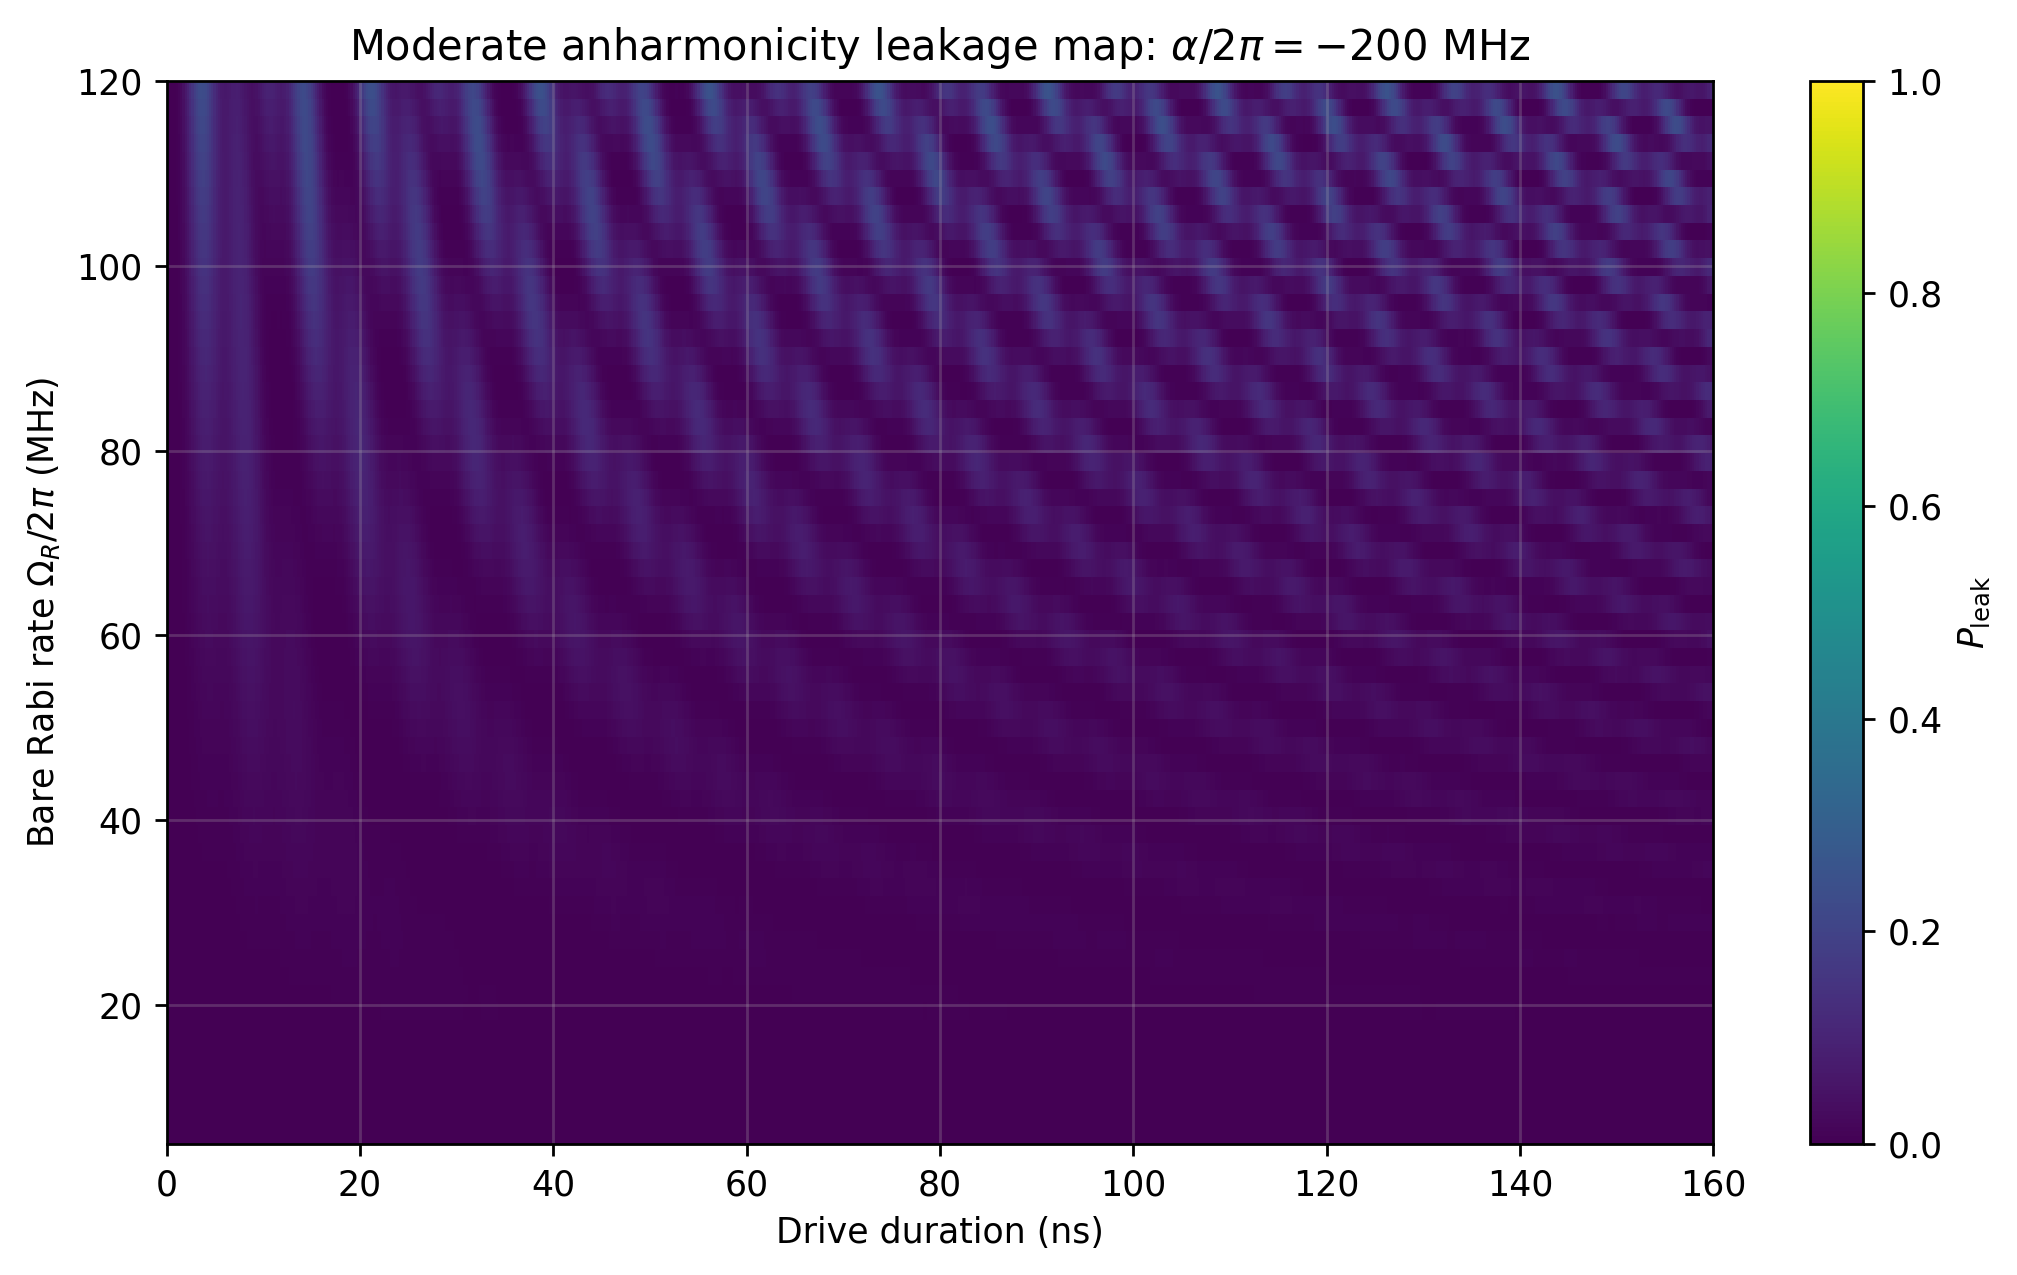

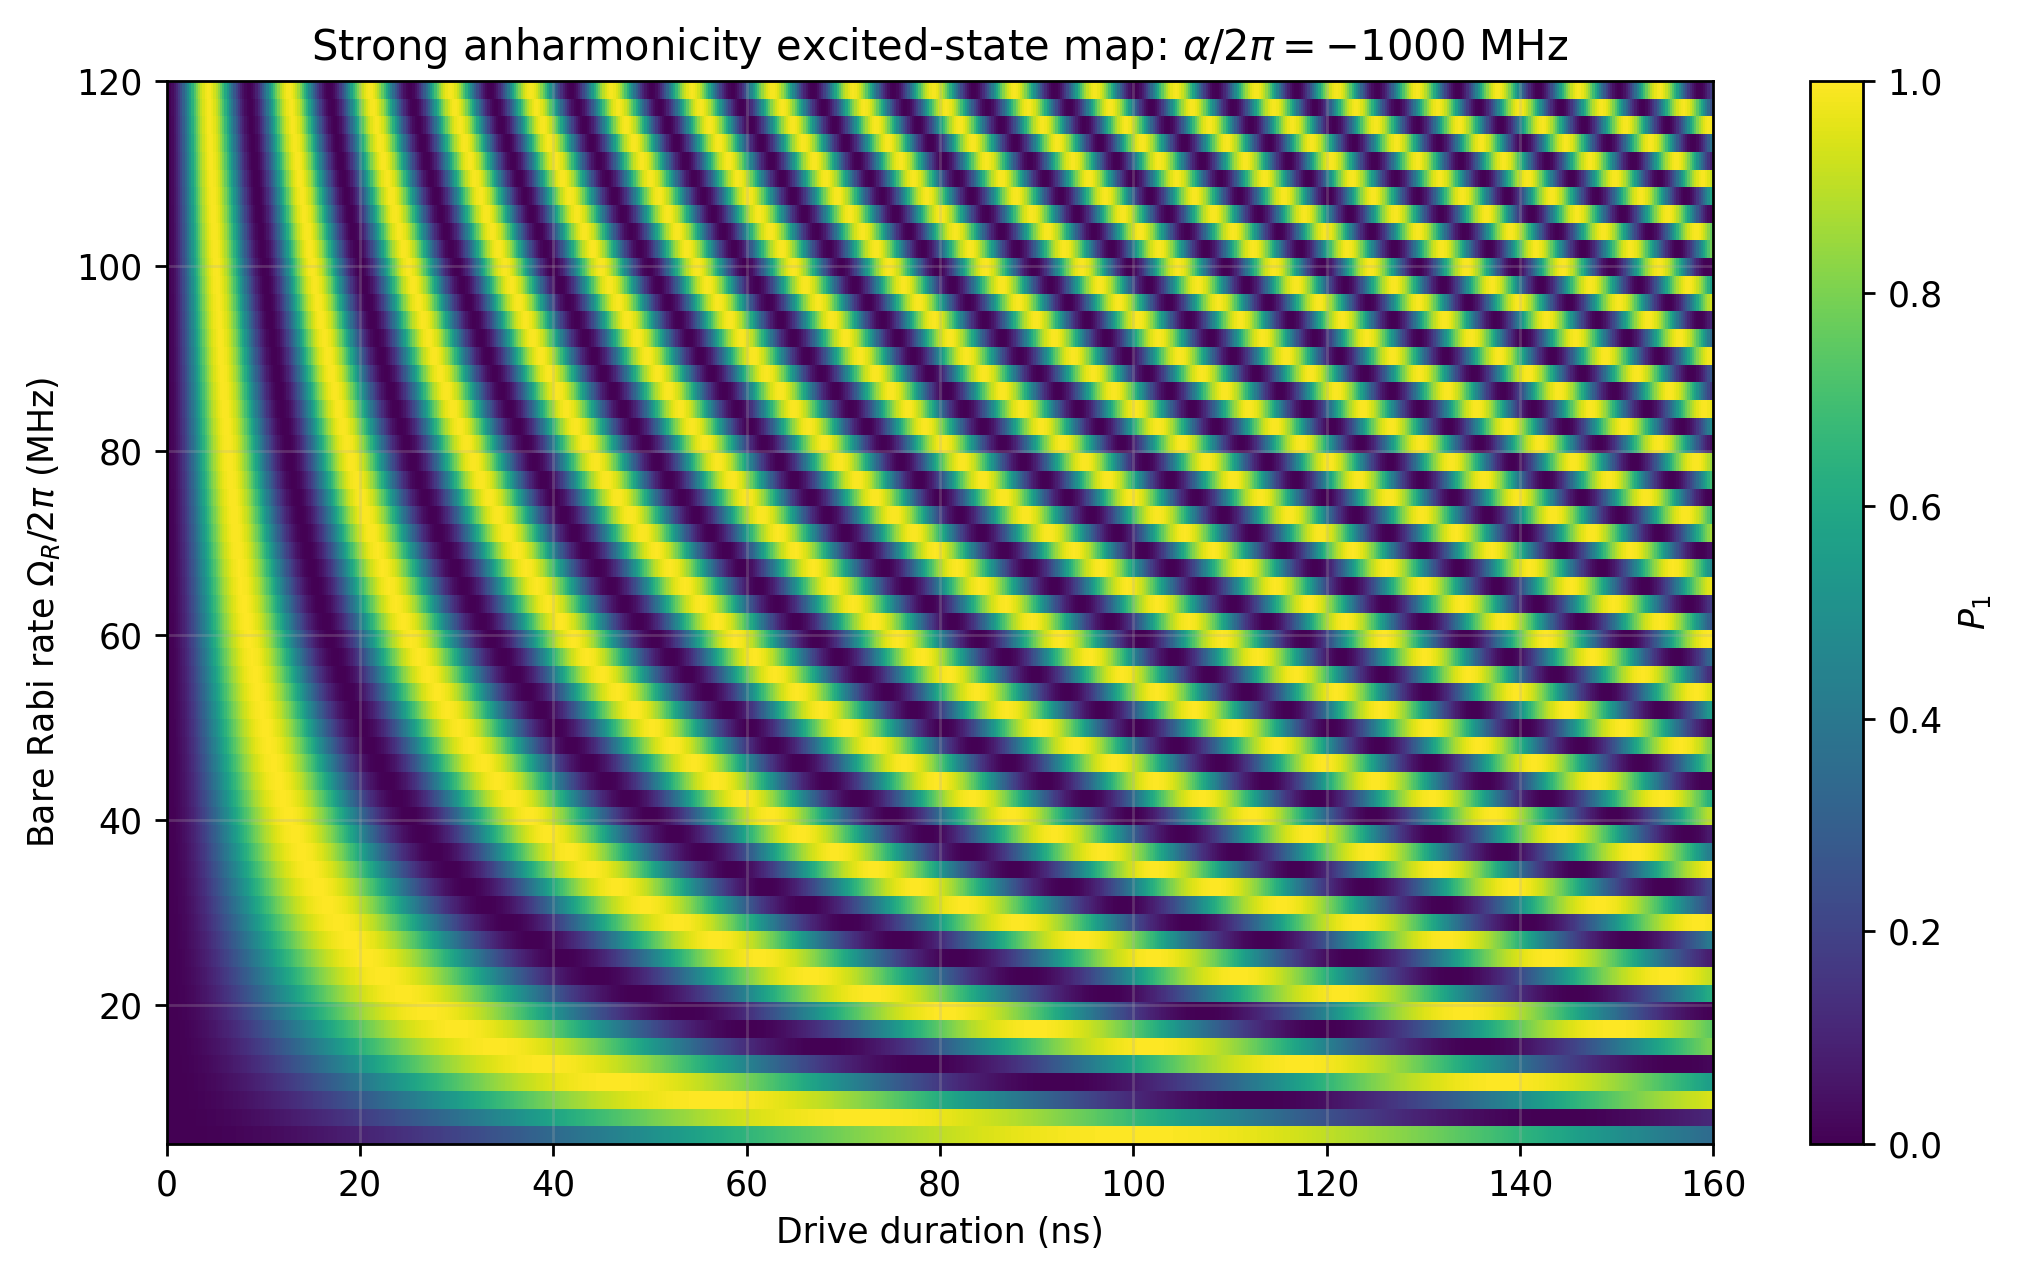

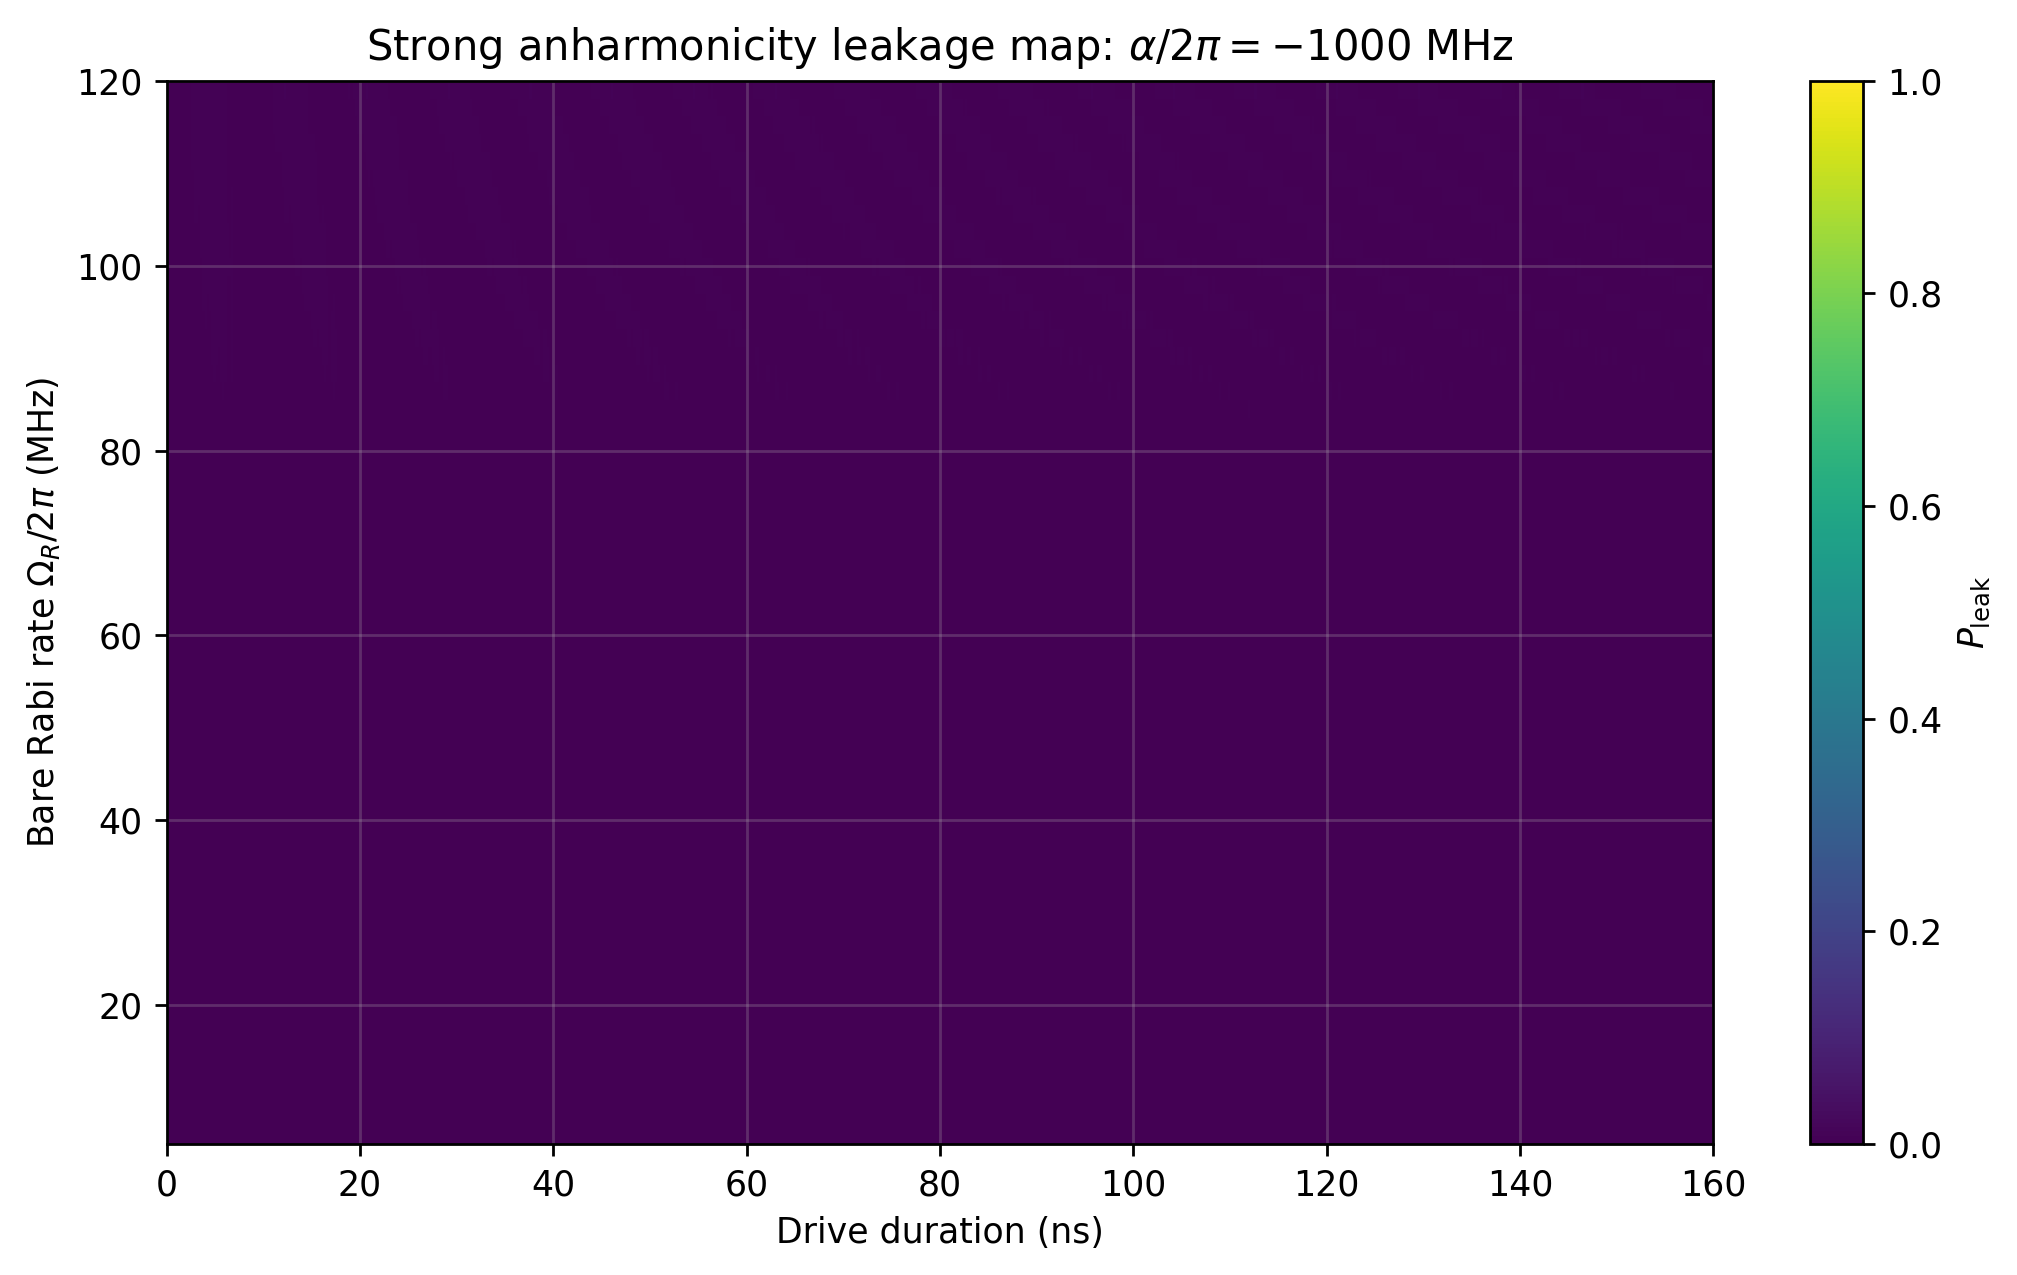

In [4]:
"""Compare Rabi dynamics for weakly and strongly anharmonic multilevel qubits."""

import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, destroy, mesolve, qeye

# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
N_LEVELS = 4

ANHARMONICITIES_MHZ = {
    "Weak": -50.0,
    "Moderate": -200.0,
    "Strong": -1000.0,
}

FIXED_RABI_RATE_MHZ = 50.0
DRIVE_DETUNING_MHZ = 0.0

TIME_MAX_NS = 160.0
TIME_POINTS = 700

DRIVE_MIN_MHZ = 5.0
DRIVE_MAX_MHZ = 120.0
DRIVE_POINTS = 60

INCLUDE_DECOHERENCE = False
T1_US = 30.0
T_PHI_US = 50.0

SHOW_EXCITED_STATE_HEATMAPS = True
SHOW_LEAKAGE_HEATMAPS = True

PLOT_DPI = 250
FIGURE_SIZE_1D = (8.6, 4.8)
FIGURE_SIZE_HEATMAP = (8.6, 5.2)

# ---------------------------------------------------
# MATPLOTLIB SETTINGS
# ---------------------------------------------------
plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def mhz_to_rad_per_ns(frequency_mhz):
    """Convert a frequency in MHz to angular frequency in rad/ns."""
    return 2.0 * np.pi * frequency_mhz / 1000.0


def build_operators(n_levels):
    """Construct oscillator ladder, number, identity, and projectors."""
    annihilation = destroy(n_levels)
    number = annihilation.dag() * annihilation
    identity = qeye(n_levels)

    projectors = [
        basis(n_levels, level) * basis(n_levels, level).dag()
        for level in range(n_levels)
    ]

    return annihilation, number, identity, projectors


def build_collapse_operators(annihilation, number):
    """Construct relaxation and pure dephasing collapse operators."""
    if not INCLUDE_DECOHERENCE:
        return []

    t1_ns = T1_US * 1000.0
    t_phi_ns = T_PHI_US * 1000.0

    return [
        np.sqrt(1.0 / t1_ns) * annihilation,
        np.sqrt(2.0 / t_phi_ns) * number,
    ]


def simulate_rabi(
    anharmonicity_mhz,
    rabi_rate_mhz,
    times_ns,
    detuning_mhz=0.0,
):
    """Simulate a driven Duffing oscillator in the rotating frame.

    Args:
        anharmonicity_mhz:
            Anharmonicity alpha / 2pi in MHz.
        rabi_rate_mhz:
            Bare zero-to-one Rabi rate Omega / 2pi in MHz.
        times_ns:
            One-dimensional array of simulation times in ns.
        detuning_mhz:
            Delta / 2pi = (omega_01 - omega_drive) / 2pi in MHz.

    Returns:
        Tuple containing level probabilities and total leakage.
    """
    annihilation, number, identity, projectors = build_operators(
        N_LEVELS
    )

    alpha = mhz_to_rad_per_ns(anharmonicity_mhz)
    omega = mhz_to_rad_per_ns(rabi_rate_mhz)
    detuning = mhz_to_rad_per_ns(detuning_mhz)

    # ---------------------------------------------------
    # Rotating-frame Duffing Hamiltonian
    #
    # H/hbar =
    # Delta*n
    # + alpha/2*n*(n - 1)
    # + Omega/2*(a + a^dagger)
    # ---------------------------------------------------
    hamiltonian = (
        detuning * number
        + 0.5 * alpha * number * (number - identity)
        + 0.5 * omega * (annihilation + annihilation.dag())
    )

    initial_state = basis(N_LEVELS, 0)

    collapse_operators = build_collapse_operators(
        annihilation,
        number,
    )

    result = mesolve(
        hamiltonian,
        initial_state,
        times_ns,
        c_ops=collapse_operators,
        e_ops=projectors,
        options={"progress_bar": False},
    )

    probabilities = np.asarray(
        result.expect,
        dtype=float,
    )

    leakage = np.sum(
        probabilities[2:, :],
        axis=0,
    )

    return probabilities, leakage


def plot_1d_comparison(times_ns):
    """Render one population plot for each anharmonicity."""
    for label, alpha_mhz in ANHARMONICITIES_MHZ.items():
        probabilities, leakage = simulate_rabi(
            anharmonicity_mhz=alpha_mhz,
            rabi_rate_mhz=FIXED_RABI_RATE_MHZ,
            times_ns=times_ns,
            detuning_mhz=DRIVE_DETUNING_MHZ,
        )

        selectivity_ratio = (
            FIXED_RABI_RATE_MHZ / abs(alpha_mhz)
        )

        fig, axis = plt.subplots(
            figsize=FIGURE_SIZE_1D
        )

        axis.plot(
            times_ns,
            probabilities[0],
            label=r"$P_0$",
        )

        axis.plot(
            times_ns,
            probabilities[1],
            label=r"$P_1$",
        )

        axis.plot(
            times_ns,
            leakage,
            label=r"$P_{\mathrm{leak}}$",
        )

        axis.set_xlabel(
            "Drive duration (ns)"
        )

        axis.set_ylabel(
            "Population probability"
        )

        axis.set_ylim(
            -0.02,
            1.02,
        )

        axis.set_title(
            f"{label} anharmonicity: "
            rf"$\alpha/2\pi={alpha_mhz:.0f}$ MHz, "
            rf"$\Omega_R/|\alpha|={selectivity_ratio:.2f}$"
        )

        axis.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
        )

        fig.tight_layout(
            rect=(0.0, 0.0, 0.82, 1.0)
        )

        plt.show()


def compute_drive_sweep(
    times_ns,
    drive_values_mhz,
    alpha_mhz,
):
    """Compute P1 and leakage over drive strength and duration."""
    p1_map = np.zeros(
        (
            drive_values_mhz.size,
            times_ns.size,
        )
    )

    leakage_map = np.zeros_like(
        p1_map
    )

    for row, drive_mhz in enumerate(
        drive_values_mhz
    ):
        probabilities, leakage = simulate_rabi(
            anharmonicity_mhz=alpha_mhz,
            rabi_rate_mhz=drive_mhz,
            times_ns=times_ns,
            detuning_mhz=DRIVE_DETUNING_MHZ,
        )

        p1_map[row, :] = probabilities[1]
        leakage_map[row, :] = leakage

    return p1_map, leakage_map


def plot_heatmap(
    data,
    times_ns,
    drive_values_mhz,
    title,
    colorbar_label,
):
    """Render one Rabi dynamics heatmap."""
    fig, axis = plt.subplots(
        figsize=FIGURE_SIZE_HEATMAP
    )

    image = axis.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            times_ns[0],
            times_ns[-1],
            drive_values_mhz[0],
            drive_values_mhz[-1],
        ],
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
        cmap="viridis",
    )

    axis.set_xlabel(
        "Drive duration (ns)"
    )

    axis.set_ylabel(
        r"Bare Rabi rate $\Omega_R/2\pi$ (MHz)"
    )

    axis.set_title(
        title
    )

    colorbar = fig.colorbar(
        image,
        ax=axis,
    )

    colorbar.set_label(
        colorbar_label
    )

    fig.tight_layout()
    plt.show()


def plot_heatmap_set(times_ns):
    """Render P1 and leakage heatmaps for every anharmonicity."""
    drive_values_mhz = np.linspace(
        DRIVE_MIN_MHZ,
        DRIVE_MAX_MHZ,
        DRIVE_POINTS,
    )

    for label, alpha_mhz in ANHARMONICITIES_MHZ.items():
        p1_map, leakage_map = compute_drive_sweep(
            times_ns=times_ns,
            drive_values_mhz=drive_values_mhz,
            alpha_mhz=alpha_mhz,
        )

        if SHOW_EXCITED_STATE_HEATMAPS:
            plot_heatmap(
                data=p1_map,
                times_ns=times_ns,
                drive_values_mhz=drive_values_mhz,
                title=(
                    f"{label} anharmonicity excited-state map: "
                    rf"$\alpha/2\pi={alpha_mhz:.0f}$ MHz"
                ),
                colorbar_label=r"$P_1$",
            )

        if SHOW_LEAKAGE_HEATMAPS:
            plot_heatmap(
                data=leakage_map,
                times_ns=times_ns,
                drive_values_mhz=drive_values_mhz,
                title=(
                    f"{label} anharmonicity leakage map: "
                    rf"$\alpha/2\pi={alpha_mhz:.0f}$ MHz"
                ),
                colorbar_label=r"$P_{\mathrm{leak}}$",
            )


def print_summary(times_ns):
    """Print numerical metrics at the fixed Rabi rate."""
    header = (
        f"{'Regime':<12}"
        f"{'alpha/2pi (MHz)':>18}"
        f"{'Omega/|alpha|':>16}"
        f"{'max P1':>12}"
        f"{'max leakage':>15}"
    )

    print(header)
    print("-" * len(header))

    for label, alpha_mhz in ANHARMONICITIES_MHZ.items():
        probabilities, leakage = simulate_rabi(
            anharmonicity_mhz=alpha_mhz,
            rabi_rate_mhz=FIXED_RABI_RATE_MHZ,
            times_ns=times_ns,
            detuning_mhz=DRIVE_DETUNING_MHZ,
        )

        ratio = (
            FIXED_RABI_RATE_MHZ / abs(alpha_mhz)
        )

        print(
            f"{label:<12}"
            f"{alpha_mhz:>18.1f}"
            f"{ratio:>16.3f}"
            f"{np.max(probabilities[1]):>12.4f}"
            f"{np.max(leakage):>15.4f}"
        )


def main():
    """Run the multilevel Rabi comparison."""
    times_ns = np.linspace(
        0.0,
        TIME_MAX_NS,
        TIME_POINTS,
    )

    print_summary(
        times_ns
    )

    plot_1d_comparison(
        times_ns
    )

    plot_heatmap_set(
        times_ns
    )


if __name__ == "__main__":
    main()